In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

### Dropped ID column because its not needed

In [98]:
df = pd.read_csv('Iris.csv')
df = df.drop('Id', axis='columns')

In [99]:
xAxis = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
yAxis = df['Species']

In [100]:
scaler = StandardScaler()
xScaled = scaler.fit_transform(xAxis)

In [101]:
xTrain, xTest, yTrain, yTest = train_test_split(
    xScaled, yAxis, test_size=0.31, random_state=10 #Tried several different test size values, found 31% to give the highest model score
)

In [102]:
model = SVC(kernel='rbf') #Switched kernel from linear to rbf, model score now 100%, up from 97%
model.fit(xTrain, yTrain)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [103]:
xVisualised = xScaled[:, :2]
modelVisualised = SVC(kernel='linear').fit(xVisualised, yAxis)
print(model.score(xTest, yTest))


1.0


In [104]:
xPlot = xScaled[:, :2] # Using SepalLengthCm & SepalWidthCm
yPlot = yAxis

modelPlot = SVC(kernel='rbf', gamma='scale')
modelPlot.fit(xPlot, yPlot)

x_min, x_max = xPlot[:, 0].min() - 1, xPlot[:, 0].max() + 1
y_min, y_max = xPlot[:, 1].min() - 1, xPlot[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

In [105]:
Z = modelPlot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

In [106]:
#plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

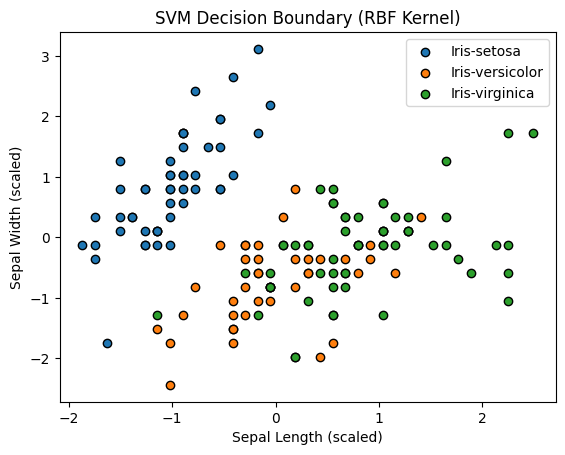

In [107]:
for idx, species in enumerate(np.unique(yPlot)):
    plt.scatter(xPlot[yPlot == species, 0],
                xPlot[yPlot == species, 1],
                label=species,
                edgecolor='k')

plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("SVM Decision Boundary (RBF Kernel)")
plt.legend()
plt.show()